In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os

sys.path.insert(1,'../')

from VI_solvers.rad_vi import RadVI 
from VI_solvers.laplace_approx import laplace_from_potential
from VI_solvers.gaussian_fbvi import Gaussian_FBVI

from utils.plotting import plot_radial_sortings, plot_2dim_scatter
from utils.elliptical_distributions import MultivariateGaussian, MultivariateLaplace, MultivariateStudent, MultivariateLogistic 

In [2]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams.update({"font.family": "serif", "font.serif": "Computer Modern"})

np.random.seed(1)

if not os.path.exists('plots/isotropic'):
    os.makedirs('plots/isotropic')

In [3]:
### Define target distribution parameters
dim = 50

target_mean  = np.zeros((dim, 1))
target_cov   = np.eye(dim)
target_scale = 1   # for logistic distribution
target_dof   = 10  # for student-t distribution

## Laplace distribution

In [4]:
### Define distribution
target_distribution = MultivariateLaplace(target_mean, target_cov)
V_laplace           = lambda x: target_distribution.potential(x)
gradV_laplace       = lambda x: target_distribution.grad_potential(x)
hessV_laplace       = lambda x: target_distribution.hess_potential(x)

In [5]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01 
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 5e-3
n_iterations   = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [6]:
### Fit Laplace approximation
mean_laplace_approx_laplace, cov_laplace_approx_laplace = laplace_from_potential(V=V_laplace, 
                                                                                 grad_V=gradV_laplace, 
                                                                                 x0=np.ones(dim),
                                                                                 method='Powell')

### Fit Gaussian FBVI
gaussian_fbvi_laplace = Gaussian_FBVI(learning_rate=learning_rate, 
                                      dim=dim, 
                                      grad_V=gradV_laplace, 
                                      hess_V=hessV_laplace,
                                      mean=np.zeros((dim, 1)),
                                      covariance=np.eye(dim))

gaussian_fbvi_laplace.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

### Fit radVI
RadVI_laplace = RadVI(truncation=truncation, 
                      mesh=mesh, 
                      dim=dim, 
                      alpha=alpha, 
                      isotropic=True,
                      V=V_laplace,
                      grad_V=gradV_laplace,
                      N_mc=n_samples_mc)

RadVI_laplace.fit(learning_rate=learning_rate,
                  num_iterations=n_iterations, 
                  sample_size=n_samples_sgd,
                  print_freq=2500)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: Powell
--------------------------------------------------

Computing numerical approximation of the Hessian of the potential function using finite differences
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.005
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466

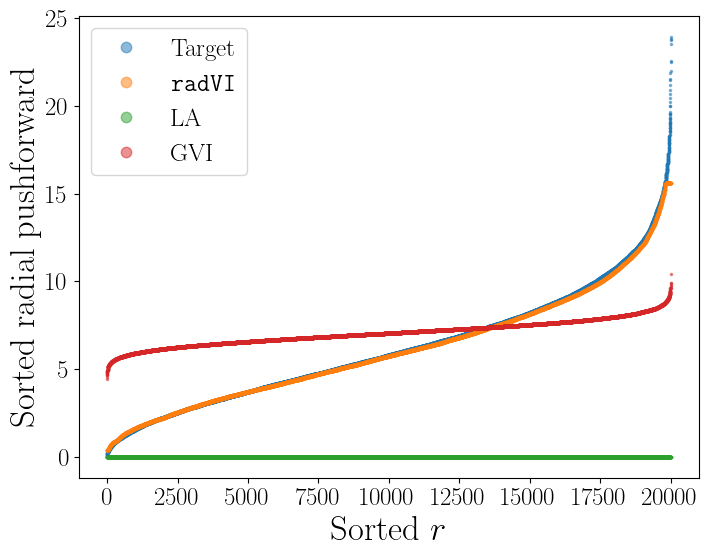

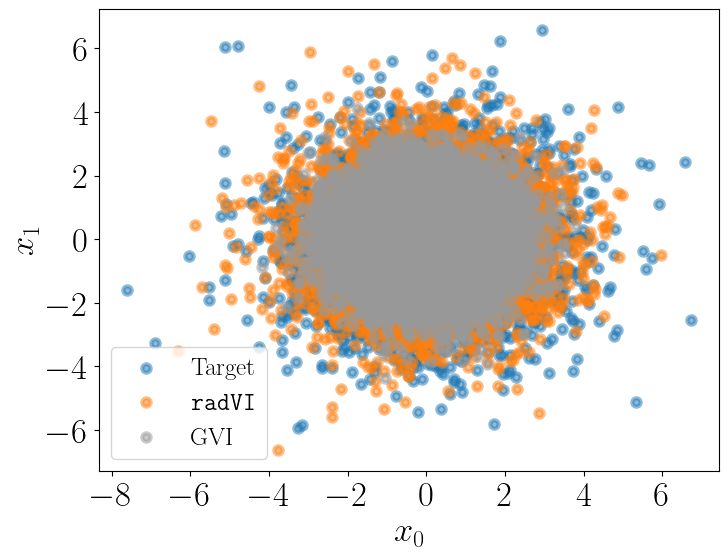

In [7]:
# Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)

# Generate Laplace approximation samples
laplace_data = np.random.multivariate_normal(mean=mean_laplace_approx_laplace.flatten(), cov=cov_laplace_approx_laplace, size=n_samples_plot).T

# Generate Gaussian FBVI samples
fbvi_data = np.random.multivariate_normal(mean=gaussian_fbvi_laplace.mean.flatten().real, cov=gaussian_fbvi_laplace.sigma.real, size=n_samples_plot).T

# Generate pushforward data
source_data      = np.random.randn(dim, n_samples_plot)
pushforward_data = RadVI_laplace.push_forward(source_data)

### Compute radial diagnostics
r_pushforward = np.linalg.norm(pushforward_data, axis=0)
r_target      = np.linalg.norm(target_data, axis=0)
r_laplace     = np.linalg.norm(laplace_data, axis=0)
r_fbvi        = np.linalg.norm(fbvi_data, axis=0)

### Plot comparison of densities
plot_radial_sortings([{"data": r_target, "label": "Target", "linestyle": "None"},
                      {"data": r_pushforward, "label": r"\texttt{radVI}", "linestyle": "None"},
                      {"data": r_laplace, "label": "LA", "linestyle": "None"},
                      {"data": r_fbvi, "label": "GVI", "linestyle": "None"}],
                      type="isotropic",
                      save_path=f'plots/isotropic/isotropic_laplace_radial_sortings_dim{dim}.pdf')

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_data, "label": r"\texttt{radVI}"},
                   {"data": fbvi_data, "label": "GVI", "color": "#999999"}],
                   save_path=f'plots/isotropic/isotropic_laplace_scatter_dim{dim}.pdf')

## Logisitc distribution

In [8]:
### Define distribution
target_distribution = MultivariateLogistic(target_mean, target_cov, scale=target_scale)
V_logistic          = lambda x: target_distribution.potential(x)
gradV_logistic      = lambda x: target_distribution.grad_potential(x)
hessV_logistic      = lambda x: target_distribution.hess_potential(x)

In [9]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01 
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 5e-2
n_iterations   = 5000 * 2   
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [10]:
### Fit Laplace approximation
mean_laplace_approx_logistic, cov_laplace_approx_logistic = laplace_from_potential(V=V_logistic, 
                                                                                   grad_V=gradV_logistic, 
                                                                                   x0=np.ones(dim),
                                                                                   method='Powell')

### Fit Gaussian FBVI
gaussian_fbvi_logistic = Gaussian_FBVI(learning_rate=learning_rate, 
                                       dim=dim, 
                                       grad_V=gradV_logistic, 
                                       hess_V=hessV_logistic,
                                       mean=np.zeros((dim, 1)),
                                       covariance=np.eye(dim))

gaussian_fbvi_logistic.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

### Fit radVI
RadVI_logistic = RadVI(truncation=truncation, 
                       mesh=mesh, 
                       dim=dim, 
                       alpha=alpha, 
                       isotropic=True,
                       V=V_logistic,
                       grad_V=gradV_logistic, 
                       N_mc=n_samples_mc)

RadVI_logistic.fit(learning_rate=learning_rate,
                   num_iterations=n_iterations, 
                   sample_size=n_samples_sgd,
                   print_freq=2500)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: Powell
--------------------------------------------------

Computing numerical approximation of the Hessian of the potential function using finite differences
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.05
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.9778834660

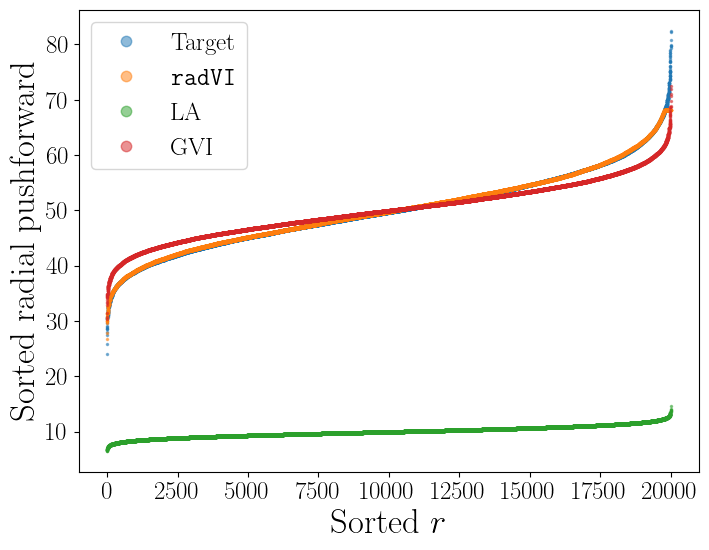

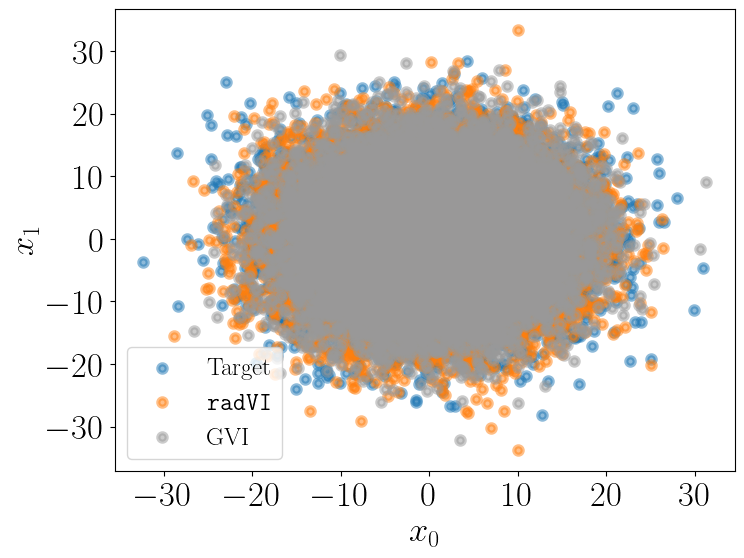

In [11]:
### Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)

### Generate Laplace approximation samples
laplace_data = np.random.multivariate_normal(mean=mean_laplace_approx_logistic.flatten(), cov=cov_laplace_approx_logistic, size=n_samples_plot).T

### Generate Gaussian FBVI samples
fbvi_data = np.random.multivariate_normal(mean=gaussian_fbvi_logistic.mean.flatten().real, cov=gaussian_fbvi_logistic.sigma.real, size=n_samples_plot).T

### Generate pushforward data
source_data      = np.random.randn(dim, n_samples_plot)
pushforward_data = RadVI_logistic.push_forward(source_data)

### Compute radial diagnostics
r_pushforward = np.linalg.norm(pushforward_data, axis=0)
r_target      = np.linalg.norm(target_data, axis=0)
r_laplace     = np.linalg.norm(laplace_data, axis=0)
r_fbvi        = np.linalg.norm(fbvi_data, axis=0)

### Plot comparison of densities
plot_radial_sortings([{"data": r_target, "label": "Target", "linestyle": "None"},
                      {"data": r_pushforward, "label": r"\texttt{radVI}", "linestyle": "None"},
                      {"data": r_laplace, "label": "LA", "linestyle": "None"},
                      {"data": r_fbvi, "label": "GVI", "linestyle": "None"}],
                      type="isotropic",
                      save_path=f'plots/isotropic/isotropic_logistic_radial_sortings_dim{dim}.pdf')

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_data, "label": r"\texttt{radVI}"},
                   {"data": fbvi_data, "label": "GVI", "color": "#999999"}],
                   save_path=f'plots/isotropic/isotropic_logistic_scatter_dim{dim}.pdf')

## Student-t distribution

In [12]:
### Define distribution
target_distribution = MultivariateStudent(target_mean, target_cov, dof=target_dof)
V_student           = lambda x: target_distribution.potential(x)
gradV_student       = lambda x: target_distribution.grad_potential(x)
hessV_student       = lambda x: target_distribution.hess_potential(x)

In [13]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01 
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 7e-3
n_iterations   = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [14]:
### Fit Laplace approximation
mean_laplace_approx_student, cov_laplace_approx_student = laplace_from_potential(V=V_student, 
                                                                                 grad_V=gradV_student, 
                                                                                 x0=np.ones(dim),
                                                                                 method='Powell')

### Fit Gaussian FBVI
gaussian_fbvi_student = Gaussian_FBVI(learning_rate=learning_rate, 
                                       dim=dim, 
                                       grad_V=gradV_student, 
                                       hess_V=hessV_student,
                                       mean=np.zeros((dim, 1)),
                                       covariance=np.eye(dim))

gaussian_fbvi_student.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

### Fit radVI
RadVI_student = RadVI(truncation=truncation, 
                      mesh=mesh, 
                      dim=dim, 
                      alpha=alpha, 
                      isotropic=True,
                      V=V_student,
                      grad_V=gradV_student,
                      N_mc=n_samples_mc)

RadVI_student.fit(learning_rate=learning_rate,
                  num_iterations=n_iterations, 
                  sample_size=n_samples_sgd,
                  print_freq=2500)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: Powell
--------------------------------------------------

Computing numerical approximation of the Hessian of the potential function using finite differences
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466

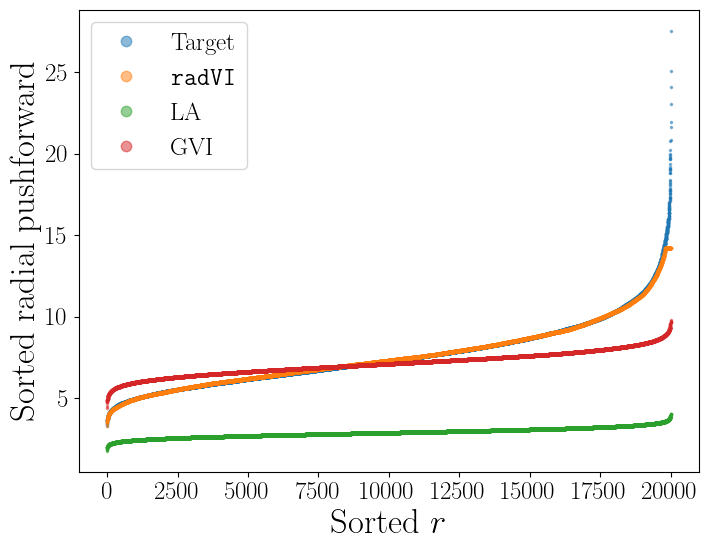

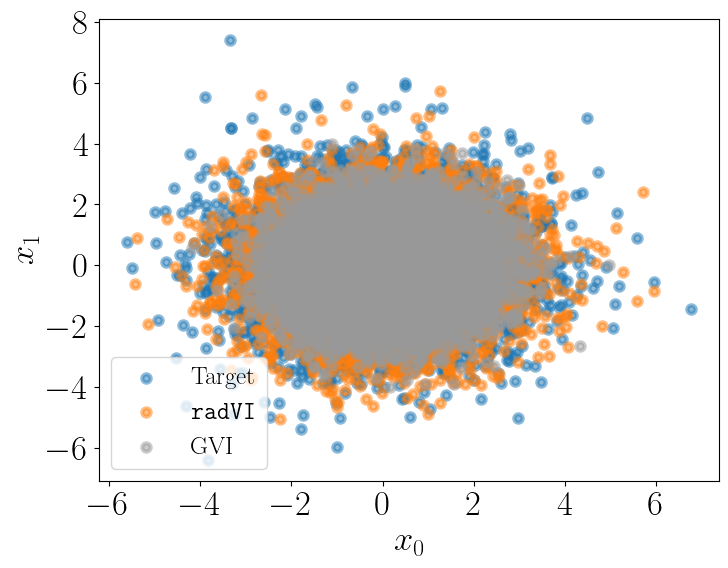

In [15]:
### Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)

### Generate Laplace approximation samples
laplace_data = np.random.multivariate_normal(mean=mean_laplace_approx_student.flatten(), cov=cov_laplace_approx_student, size=n_samples_plot).T

### Generate Gaussian FBVI samples
fbvi_data = np.random.multivariate_normal(mean=gaussian_fbvi_student.mean.flatten().real, cov=gaussian_fbvi_student.sigma.real, size=n_samples_plot).T

### Generate pushforward data
source_data      = np.random.randn(dim, n_samples_plot)
pushforward_data = RadVI_student.push_forward(source_data)

### Compute radial diagnostics
r_pushforward = np.linalg.norm(pushforward_data, axis=0)
r_target      = np.linalg.norm(target_data, axis=0)
r_laplace     = np.linalg.norm(laplace_data, axis=0)
r_fbvi        = np.linalg.norm(fbvi_data, axis=0)

### Plot comparison of densities
plot_radial_sortings([{"data": r_target, "label": "Target", "linestyle": "None" },
                      {"data": r_pushforward, "label": r"\texttt{radVI}", "linestyle": "None"},
                      {"data": r_laplace, "label": "LA", "linestyle": "None"},
                      {"data": r_fbvi, "label": "GVI", "linestyle": "None"}],
                      type="isotropic",
                      save_path=f'plots/isotropic/isotropic_student_dof_{int(target_distribution.dof)}_radial_sortings_dim{dim}.pdf')

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_data, "label": r"\texttt{radVI}"},
                   {"data": fbvi_data, "label": "GVI", "color": "#999999"}],
                   save_path=f'plots/isotropic/isotropic_student_dof_{int(target_distribution.dof)}_scatter_dim{dim}.pdf')